# NOTEBOOK 06 — train final CatBoost meta

Цель:
- получить второй независимый источник сигнала для ансамбля;
- обучить `41 one-vs-rest CatBoost` по фиксированным 5-fold;
- использовать:
  - `main categorical` → **`cat_feature__code`**
  - `main numeric`
  - `top-300 extra`
  - `null features` и `row stats` из `NOTEBOOK 02`
  - `global aggs` и `null_svd` из `NOTEBOOK 04`
  - `L1 meta-features` из `NOTEBOOK 03` (**кроме собственного target**)

Что сохраняем:
- `artifacts/preds/final_catboost_oof.parquet`
- `artifacts/preds/final_catboost_test.parquet`
- `artifacts/logs/final_catboost_scores.csv`

Особенности:
- upstream-артефакты читаются как Kaggle input datasets;
- `cat_feature__code` используются в CatBoost как `cat_features`;
- для каждого target колонка `meta_<target>` исключается из признаков;
- train/test выравниваются по `customer_id`;
- **seed averaging**: 5 seeds для стабильных test-предсказаний;
- обучаем **все 41 target**.


In [1]:
# =========================
# Imports
# =========================
from pathlib import Path
import gc
import json
import warnings

import numpy as np
import pandas as pd
import polars as pl
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)


polars.config.Config

In [2]:
# =========================
# Paths
# =========================

# raw competition data
DATA_DIR = Path("/kaggle/input/datasets/hatab123/data-fusion-contest-2026/")

# output dataset from NOTEBOOK 00
NB00_DIR = Path("/kaggle/input/notebooks/viktoriasvetankova/00-schema-and-folds2803/prepared")

# output dataset from NOTEBOOK 02
NB02_DIR = Path("/kaggle/input/notebooks/viktoriasvetankova/02-build-base-features2803/prepared")

# output dataset from NOTEBOOK 03
NB03_DIR = Path("/kaggle/input/notebooks/viktoriasvetankova/03-build-meta-oof-lgbm-memory-safe2803/prepared")

# output dataset from NOTEBOOK 04
NB04_DIR = Path("/kaggle/input/notebooks/viktoriasvetankova/04-build-global-aggs-and-null-features2803/prepared")

# current-session working dir
WORK_DIR = Path("/kaggle/working/prepared")
WORK_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATHS = {
    "train_target": DATA_DIR / "train_target.parquet",
}

UPSTREAM_PATHS = {
    "folds": NB00_DIR / "artifacts" / "config" / "folds.parquet",
    "target_cols": NB00_DIR / "artifacts" / "config" / "target_cols.json",

    "train_base": NB02_DIR / "artifacts" / "features" / "train_base_features.parquet",
    "test_base": NB02_DIR / "artifacts" / "features" / "test_base_features.parquet",
    "base_feature_cols": NB02_DIR / "artifacts" / "features" / "base_feature_cols.json",

    "l1_oof": NB03_DIR / "artifacts" / "meta" / "l1_lgbm_oof.parquet",
    "l1_test": NB03_DIR / "artifacts" / "meta" / "l1_lgbm_test.parquet",

    "train_aggs": NB04_DIR / "artifacts" / "aggs" / "train_global_aggs.parquet",
    "test_aggs": NB04_DIR / "artifacts" / "aggs" / "test_global_aggs.parquet",
    "train_null_svd": NB04_DIR / "artifacts" / "aggs" / "train_null_svd.parquet",
    "test_null_svd": NB04_DIR / "artifacts" / "aggs" / "test_null_svd.parquet",
}

ARTIFACTS_DIR = WORK_DIR / "artifacts"
PREDS_DIR = ARTIFACTS_DIR / "preds"
LOG_DIR = ARTIFACTS_DIR / "logs"

PREDS_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR :", DATA_DIR)
print("NB00_DIR :", NB00_DIR)
print("NB02_DIR :", NB02_DIR)
print("NB03_DIR :", NB03_DIR)
print("NB04_DIR :", NB04_DIR)
print("WORK_DIR :", WORK_DIR)

print("\nRaw paths:")
for k, v in RAW_PATHS.items():
    print(f"{k:>16}: {v} | exists={v.exists()}")

print("\nUpstream paths:")
for k, v in UPSTREAM_PATHS.items():
    print(f"{k:>16}: {v} | exists={v.exists()}")


DATA_DIR : /kaggle/input/datasets/hatab123/data-fusion-contest-2026
NB00_DIR : /kaggle/input/notebooks/viktoriasvetankova/00-schema-and-folds2803/prepared
NB02_DIR : /kaggle/input/notebooks/viktoriasvetankova/02-build-base-features2803/prepared
NB03_DIR : /kaggle/input/notebooks/viktoriasvetankova/03-build-meta-oof-lgbm-memory-safe2803/prepared
NB04_DIR : /kaggle/input/notebooks/viktoriasvetankova/04-build-global-aggs-and-null-features2803/prepared
WORK_DIR : /kaggle/working/prepared

Raw paths:
    train_target: /kaggle/input/datasets/hatab123/data-fusion-contest-2026/train_target.parquet | exists=True

Upstream paths:
           folds: /kaggle/input/notebooks/viktoriasvetankova/00-schema-and-folds2803/prepared/artifacts/config/folds.parquet | exists=True
     target_cols: /kaggle/input/notebooks/viktoriasvetankova/00-schema-and-folds2803/prepared/artifacts/config/target_cols.json | exists=True
      train_base: /kaggle/input/notebooks/viktoriasvetankova/02-build-base-features2803/pre

In [3]:
# =========================
# Config
# =========================
SEED = 42

ID_COL = "customer_id"
FOLD_COL = "fold"
META_PREFIX = "meta_"

USE_GPU = True

CB_PARAMS = {
    "iterations": 800,
    "depth": 4,
    "learning_rate": 0.05,
    "l2_leaf_reg": 3.0,
    "random_strength": 2,
    "bagging_temperature": 0,
    "border_count": 128,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "nan_mode": "Min",
    "task_type": "GPU",
    "devices": "0",
    "random_seed": SEED,
    "verbose": 200,
    "early_stopping_rounds": 100,
    "auto_class_weights": "Balanced",
}

if USE_GPU:
    CB_PARAMS.update({
        "task_type": "GPU",
        "devices": "0",
    })
else:
    CB_PARAMS.update({
        "task_type": "CPU",
        "thread_count": 4,
    })


In [4]:
# =========================
# Helpers
# =========================
def report_mem_pl(df: pl.DataFrame, name: str):
    mem_mb = df.estimated_size() / 1024**2
    print(f"{name}: shape={df.shape}, memory={mem_mb:,.2f} MB")

def downcast_pl(df: pl.DataFrame) -> pl.DataFrame:
    exprs = []
    for col, dtype in zip(df.columns, df.dtypes):
        if dtype == pl.Float64:
            exprs.append(pl.col(col).cast(pl.Float32))
        elif dtype == pl.Int64:
            exprs.append(pl.col(col).cast(pl.Int32))
        elif dtype == pl.UInt64:
            exprs.append(pl.col(col).cast(pl.UInt32))
        else:
            exprs.append(pl.col(col))
    return df.select(exprs)

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def safe_auc(y_true, y_pred):
    if np.min(y_true) == np.max(y_true):
        return np.nan
    return roc_auc_score(y_true, y_pred)

def make_meta_name(target_name: str) -> str:
    return f"{META_PREFIX}{target_name}"

def make_pred_col(target_name: str) -> str:
    return target_name

def to_pandas_preserve_dtypes(df: pl.DataFrame) -> pd.DataFrame:
    pdf = df.to_pandas(use_pyarrow_extension_array=False)
    return pdf


In [5]:
# =========================
# Load upstream artifacts (ALL 41 targets)
# =========================
target_cols = load_json(UPSTREAM_PATHS["target_cols"])

base_meta = load_json(UPSTREAM_PATHS["base_feature_cols"])

folds_df = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["folds"]).select([ID_COL, FOLD_COL]))
target_df = downcast_pl(pl.read_parquet(RAW_PATHS["train_target"]).select([ID_COL] + target_cols))

train_base = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["train_base"]))
test_base = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["test_base"]))

l1_oof = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["l1_oof"]))
l1_test = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["l1_test"]))

train_aggs = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["train_aggs"]))
test_aggs = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["test_aggs"]))

train_null_svd = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["train_null_svd"]))
test_null_svd = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["test_null_svd"]))

report_mem_pl(folds_df, "folds_df")
report_mem_pl(target_df, "target_df")
report_mem_pl(train_base, "train_base")
report_mem_pl(test_base, "test_base")
report_mem_pl(l1_oof, "l1_oof")
report_mem_pl(l1_test, "l1_test")
report_mem_pl(train_aggs, "train_aggs")
report_mem_pl(test_aggs, "test_aggs")
report_mem_pl(train_null_svd, "train_null_svd")
report_mem_pl(test_null_svd, "test_null_svd")


folds_df: shape=(750000, 2), memory=3.58 MB
target_df: shape=(750000, 42), memory=120.16 MB
train_base: shape=(750000, 981), memory=2,876.05 MB
test_base: shape=(250000, 981), memory=958.68 MB
l1_oof: shape=(750000, 42), memory=120.16 MB
l1_test: shape=(250000, 42), memory=40.05 MB
train_aggs: shape=(750000, 8), memory=22.89 MB
test_aggs: shape=(250000, 8), memory=7.63 MB
train_null_svd: shape=(750000, 21), memory=60.08 MB
test_null_svd: shape=(250000, 21), memory=20.03 MB


In [6]:
# =========================
# Feature groups from NOTEBOOK 02 / 03 / 04
# =========================
main_num_cols = base_meta["main_num_cols"]
main_cat_code_cols = base_meta["main_cat_code_cols"]
main_cat_freq_cols = base_meta["main_cat_freq_cols"]
extra_top300_cols = base_meta["extra_top300_cols"]
null_feature_cols = base_meta["null_feature_cols"]
row_stat_cols = base_meta["row_stat_cols"]

aggs_feature_cols = [c for c in train_aggs.columns if c != ID_COL]
null_svd_cols = [c for c in train_null_svd.columns if c != ID_COL]
l1_meta_cols = [c for c in l1_oof.columns if c != ID_COL]

common_feature_cols = (
    main_cat_code_cols
    + main_cat_freq_cols
    + main_num_cols
    + extra_top300_cols
    + null_feature_cols
    + row_stat_cols
    + aggs_feature_cols
    + null_svd_cols
)

print("main_cat_code_cols :", len(main_cat_code_cols))
print("main_num_cols      :", len(main_num_cols))
print("main_cat_freq_cols :", len(main_cat_freq_cols))
print("extra_top300_cols  :", len(extra_top300_cols))
print("null_feature_cols  :", len(null_feature_cols))
print("row_stat_cols      :", len(row_stat_cols))
print("aggs_feature_cols  :", len(aggs_feature_cols))
print("null_svd_cols      :", len(null_svd_cols))
print("l1_meta_cols       :", len(l1_meta_cols))
print("common_feature_cols:", len(common_feature_cols))

print("\nFirst cat code cols:", main_cat_code_cols[:10])
print("First aggs cols    :", aggs_feature_cols[:10])
print("First null_svd cols:", null_svd_cols[:5])
print("First meta cols    :", l1_meta_cols[:5])


main_cat_code_cols : 67
main_num_cols      : 132
main_cat_freq_cols : 67
extra_top300_cols  : 300
null_feature_cols  : 4
row_stat_cols      : 10
aggs_feature_cols  : 7
null_svd_cols      : 20
l1_meta_cols       : 41
common_feature_cols: 607

First cat code cols: ['cat_feature_1__code', 'cat_feature_2__code', 'cat_feature_3__code', 'cat_feature_4__code', 'cat_feature_5__code', 'cat_feature_6__code', 'cat_feature_7__code', 'cat_feature_8__code', 'cat_feature_9__code', 'cat_feature_10__code']
First aggs cols    : ['sum_extra', 'mean_extra', 'std_extra', 'min_extra', 'max_extra', 'count_nonzero_extra', 'count_null_extra']
First null_svd cols: ['null_svd_00', 'null_svd_01', 'null_svd_02', 'null_svd_03', 'null_svd_04']
First meta cols    : ['meta_target_1_1', 'meta_target_1_2', 'meta_target_1_3', 'meta_target_1_4', 'meta_target_1_5']


In [7]:
# =========================
# Align train/test tables
# =========================
train_features = (
    train_base
    .join(train_aggs,  on=ID_COL, how="left")
    .join(train_null_svd, on=ID_COL, how="inner")
    .join(l1_oof, on=ID_COL, how="inner")
    .sort(ID_COL)
)

test_features = (
    test_base
    .join(test_aggs,  on=ID_COL, how="left")
    .join(test_null_svd, on=ID_COL, how="inner")
    .join(l1_test, on=ID_COL, how="inner")
    .sort(ID_COL)
)

metadata_df = (
    folds_df
    .join(target_df, on=ID_COL, how="inner")
    .sort(ID_COL)
)

assert train_features.height == metadata_df.height, "train rows mismatch after metadata join"
assert train_features.get_column(ID_COL).to_list() == metadata_df.get_column(ID_COL).to_list(), "customer_id alignment mismatch between train_features and metadata"

report_mem_pl(train_features, "train_features")
report_mem_pl(test_features, "test_features")
report_mem_pl(metadata_df, "metadata_df")


train_features: shape=(750000, 1049), memory=3,070.59 MB
test_features: shape=(250000, 1049), memory=1,023.53 MB
metadata_df: shape=(750000, 43), memory=120.88 MB


In [8]:
# =========================
# Convert once to pandas / numpy
# =========================
train_ids = train_features.get_column(ID_COL).to_numpy()
test_ids = test_features.get_column(ID_COL).to_numpy()

Y = metadata_df.select(target_cols).to_numpy()
if Y.dtype != np.int8:
    Y = Y.astype(np.int8, copy=False)

fold_array = metadata_df.get_column(FOLD_COL).to_numpy()

train_pd = to_pandas_preserve_dtypes(train_features)
test_pd = to_pandas_preserve_dtypes(test_features)

# CatBoost: code-columns must stay integer-like and be passed via cat_features
for col in main_cat_code_cols:
    if col in train_pd.columns:
        train_pd[col] = train_pd[col].astype("Int32")
        test_pd[col] = test_pd[col].astype("Int32")

# numeric columns -> float32 when possible
non_id_cols = [c for c in train_pd.columns if c != ID_COL]
for col in non_id_cols:
    if col not in main_cat_code_cols:
        train_pd[col] = train_pd[col].astype(np.float32, copy=False)
        test_pd[col] = test_pd[col].astype(np.float32, copy=False)

print("train_pd:", train_pd.shape)
print("test_pd :", test_pd.shape)
print("Y       :", Y.shape, Y.dtype)
print("folds   :", np.unique(fold_array))


train_pd: (750000, 1049)
test_pd : (250000, 1049)
Y       : (750000, 41) int8
folds   : [0 1 2 3 4]


In [9]:
# =========================
# Precompute fold indices
# =========================
unique_folds = np.sort(np.unique(fold_array))
fold_indices = {}

for fold in unique_folds:
    tr_idx = np.where(fold_array != fold)[0]
    va_idx = np.where(fold_array == fold)[0]
    fold_indices[int(fold)] = {
        "train": tr_idx,
        "valid": va_idx,
    }

for fold in unique_folds:
    print(
        f"fold={fold} | train={len(fold_indices[int(fold)]['train']):,} | "
        f"valid={len(fold_indices[int(fold)]['valid']):,}"
    )


fold=0 | train=600,105 | valid=149,895
fold=1 | train=599,970 | valid=150,030
fold=2 | train=599,983 | valid=150,017
fold=3 | train=599,876 | valid=150,124
fold=4 | train=600,066 | valid=149,934


## Финальный CatBoost meta loop

Для каждого `target`:
- берём общий набор признаков;
- добавляем `meta_*` от всех target'ов, кроме собственного;
- обучаем CatBoost по фиксированным фолдам;
- сохраняем OOF и среднее test prediction по фолдам.


In [10]:
# Полный набор общих признаков (как common_feature_cols из ячейки выше)
# CatBoost использует все доступные фичи, включая null_feature_cols и row_stat_cols
common_feature_cols_final = (
    main_cat_code_cols
    + main_cat_freq_cols
    + main_num_cols
    + extra_top300_cols
    + null_feature_cols
    + row_stat_cols
    + aggs_feature_cols
    + null_svd_cols
)


In [11]:
# =========================
# Final CatBoost OOF training loop (with seed averaging)
# =========================
n_train = train_pd.shape[0]
n_test = test_pd.shape[0]
n_targets = len(target_cols)

oof_preds = np.zeros((n_train, n_targets), dtype=np.float32)
test_preds = np.zeros((n_test, n_targets), dtype=np.float32)

scores_log = []

for t_idx, tgt in enumerate(target_cols):
    print(f"\n=== [{t_idx+1:02d}/{n_targets}] {tgt} ===")

    y = Y[:, t_idx]
    own_meta_col = make_meta_name(tgt)
    meta_other_cols = [c for c in l1_meta_cols if c != own_meta_col]

    feature_cols_t = common_feature_cols_final + meta_other_cols
    cat_features_t = [c for c in main_cat_code_cols if c in feature_cols_t]

    target_test_pred = np.zeros(n_test, dtype=np.float32)
    fold_scores = []

    X_full = train_pd[feature_cols_t]
    X_test_full = test_pd[feature_cols_t]

    for fold in unique_folds:
        tr_idx = fold_indices[int(fold)]["train"]
        va_idx = fold_indices[int(fold)]["valid"]

        X_tr = X_full.iloc[tr_idx]
        X_va = X_full.iloc[va_idx]
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        model = CatBoostClassifier(
            **{
                **CB_PARAMS,
            }
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_features_t,
            eval_set=(X_va, y_va),
            use_best_model=True,
        )

        # OOF: use only the first seed to avoid leakage
        va_pred = model.predict_proba(X_va)[:, 1].astype(np.float32, copy=False)
        te_pred = model.predict_proba(X_test_full)[:, 1].astype(np.float32, copy=False)

        oof_preds[va_idx, t_idx] = va_pred
        target_test_pred += te_pred / len(unique_folds)

        fold_auc = safe_auc(y_va, va_pred)
        fold_scores.append(fold_auc)

        scores_log.append({
            "target": tgt,
            "fold": int(fold),
            "valid_auc": None if np.isnan(fold_auc) else float(fold_auc),
            "n_features": int(len(feature_cols_t)),
            "n_meta_other_cols": int(len(meta_other_cols)),
            "n_cat_features": int(len(cat_features_t)),
            "best_iteration": int(model.get_best_iteration()) if model.get_best_iteration() is not None else None,
        })

        print(
            f"fold={fold} | "
            f"auc={None if np.isnan(fold_auc) else round(float(fold_auc), 6)} | "
            f"best_iter={model.get_best_iteration()}"
        )

        del X_tr, X_va, y_tr, y_va, va_pred, model, te_pred
        gc.collect()

    test_preds[:, t_idx] = target_test_pred

    target_oof_auc = safe_auc(y, oof_preds[:, t_idx])
    print(
        f"{tgt}: OOF AUC = "
        f"{None if np.isnan(target_oof_auc) else round(float(target_oof_auc), 6)} | "
        f"fold_mean = {None if np.isnan(np.nanmean(fold_scores)) else round(float(np.nanmean(fold_scores)), 6)}"
    )

    del X_full, X_test_full, y, target_test_pred, fold_scores
    gc.collect()



=== [01/41] target_1_1 ===


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8407170	best: 0.8407170 (0)	total: 331ms	remaining: 4m 24s
200:	test: 0.9099383	best: 0.9099383 (200)	total: 41s	remaining: 2m 2s
400:	test: 0.9132342	best: 0.9132342 (400)	total: 1m 22s	remaining: 1m 21s
600:	test: 0.9137964	best: 0.9137964 (600)	total: 2m 2s	remaining: 40.6s
799:	test: 0.9143915	best: 0.9144563 (782)	total: 2m 42s	remaining: 0us
bestTest = 0.9144562781
bestIteration = 782
Shrink model to first 783 iterations.
fold=0 | auc=0.914456 | best_iter=782


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8443365	best: 0.8443365 (0)	total: 244ms	remaining: 3m 14s
200:	test: 0.9113213	best: 0.9113213 (200)	total: 42.2s	remaining: 2m 5s
400:	test: 0.9136430	best: 0.9136430 (400)	total: 1m 22s	remaining: 1m 22s
600:	test: 0.9143458	best: 0.9144780 (584)	total: 2m 3s	remaining: 40.9s
bestTest = 0.9145040512
bestIteration = 624
Shrink model to first 625 iterations.
fold=1 | auc=0.914504 | best_iter=624


...

0:	test: 0.7048236	best: 0.7048236 (0)	total: 245ms	remaining: 3m 16s
200:	test: 0.7542702	best: 0.7542702 (200)	total: 41.9s	remaining: 2m 4s
400:	test: 0.7577336	best: 0.7577336 (400)	total: 1m 22s	remaining: 1m 21s
600:	test: 0.7594757	best: 0.7594757 (600)	total: 2m 2s	remaining: 40.6s
799:	test: 0.7604593	best: 0.7604593 (799)	total: 2m 42s	remaining: 0us
bestTest = 0.7604593039
bestIteration = 799
fold=2 | auc=0.760459 | best_iter=799


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7062198	best: 0.7062198 (0)	total: 250ms	remaining: 3m 20s
200:	test: 0.7542551	best: 0.7542551 (200)	total: 41.7s	remaining: 2m 4s
400:	test: 0.7578109	best: 0.7578109 (400)	total: 1m 22s	remaining: 1m 21s
600:	test: 0.7595200	best: 0.7595200 (600)	total: 2m 2s	remaining: 40.6s
799:	test: 0.7605091	best: 0.7605096 (798)	total: 2m 42s	remaining: 0us
bestTest = 0.7605095804
bestIteration = 798
Shrink model to first 799 iterations.
fold=3 | auc=0.76051 | best_iter=798


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7065581	best: 0.7065581 (0)	total: 258ms	remaining: 3m 26s
200:	test: 0.7544689	best: 0.7544689 (200)	total: 41.7s	remaining: 2m 4s
400:	test: 0.7582181	best: 0.7582181 (400)	total: 1m 22s	remaining: 1m 21s
600:	test: 0.7600238	best: 0.7600238 (600)	total: 2m 2s	remaining: 40.7s
799:	test: 0.7609695	best: 0.7609697 (798)	total: 2m 43s	remaining: 0us
bestTest = 0.7609696984
bestIteration = 798
Shrink model to first 799 iterations.
fold=4 | auc=0.76097 | best_iter=798
target_10_1: OOF AUC = 0.760666 | fold_mean = 0.760676


In [12]:
# =========================
# Build output tables
# =========================
pred_cols = [make_pred_col(t) for t in target_cols]

oof_df = pl.DataFrame({ID_COL: train_ids})
test_df = pl.DataFrame({ID_COL: test_ids})

for i, col in enumerate(pred_cols):
    oof_df = oof_df.with_columns(pl.Series(col, oof_preds[:, i]))
    test_df = test_df.with_columns(pl.Series(col, test_preds[:, i]))

scores_df = pl.DataFrame(scores_log)

report_mem_pl(oof_df, "oof_df")
report_mem_pl(test_df, "test_df")
report_mem_pl(scores_df, "scores_df")

per_target_oof = []
for i, tgt in enumerate(target_cols):
    auc = safe_auc(Y[:, i], oof_preds[:, i])
    per_target_oof.append(auc)

macro_auc = float(np.nanmean(per_target_oof))
print("Macro OOF AUC:", round(macro_auc, 6))

oof_df: shape=(750000, 42), memory=120.16 MB
test_df: shape=(250000, 42), memory=40.05 MB
scores_df: shape=(205, 7), memory=0.01 MB
Macro OOF AUC: 0.832756


In [13]:
# =========================================
# Per-target OOF AUC table
# =========================================
target_auc_rows = []

for t_idx, tgt in enumerate(target_cols):
    target_auc = safe_auc(Y[:, t_idx], oof_preds[:, t_idx])
    target_auc_rows.append({
        "target": tgt,
        "oof_auc": None if np.isnan(target_auc) else float(target_auc),
    })

target_auc_df = pl.DataFrame(target_auc_rows).sort("oof_auc", descending=True)

display(target_auc_df)


target,oof_auc
str,f64
"""target_2_8""",0.981526
"""target_8_1""",0.978274
"""target_3_5""",0.974637
"""target_6_5""",0.937817
"""target_3_4""",0.936794
"""target_9_8""",0.935366
"""target_2_2""",0.933038
"""target_9_4""",0.91513
"""target_1_1""",0.913543


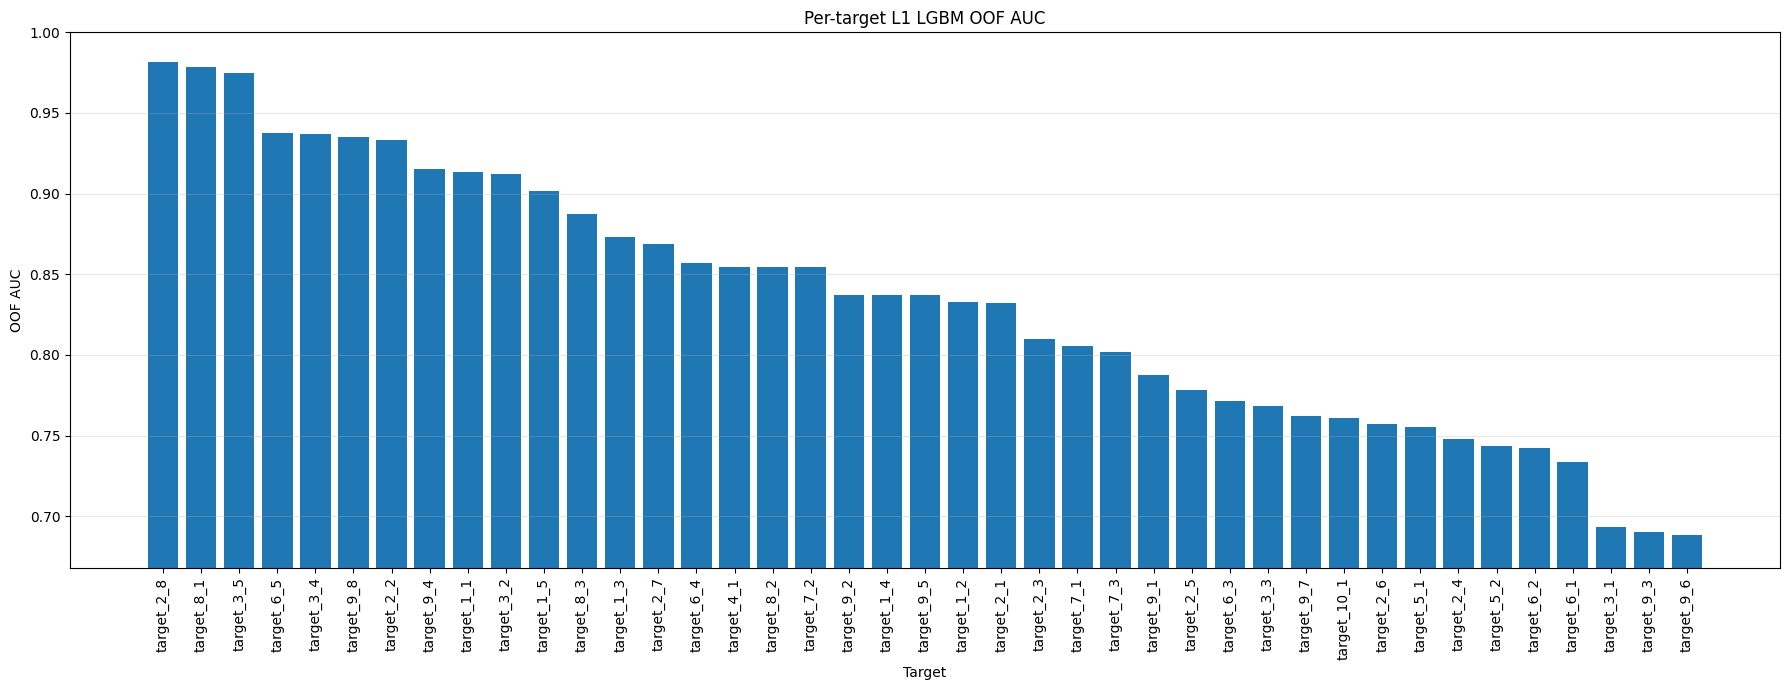

In [15]:
# =========================================
# Visualization: vertical bar chart of per-target OOF AUC
# =========================================
import matplotlib.pyplot as plt

# convert from polars to python lists
plot_df = target_auc_df.sort("oof_auc", descending=True)

targets = plot_df.get_column("target").to_list()
aucs = plot_df.get_column("oof_auc").to_list()

x = np.arange(len(targets))

plt.figure(figsize=(18, 7))
plt.bar(x, aucs)

plt.xticks(x, targets, rotation=90)
plt.ylabel("OOF AUC")
plt.xlabel("Target")
plt.title("Per-target L1 LGBM OOF AUC")
plt.ylim(max(0.0, min(aucs) - 0.02), min(1.0, max(aucs) + 0.02))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# =========================
# Save artifacts
# =========================
oof_path = PREDS_DIR / "final_catboost_oof.parquet"
test_path = PREDS_DIR / "final_catboost_test.parquet"
scores_path = LOG_DIR / "final_catboost_scores.csv"
target_auc_path = LOG_DIR / "final_catboost_target_auc.csv"
summary_path = LOG_DIR / "final_catboost_summary.json"

oof_df.write_parquet(oof_path)
test_df.write_parquet(test_path)
scores_df.write_csv(scores_path)
target_auc_df.write_csv(target_auc_path)

summary = {
    "n_train_rows": int(n_train),
    "n_test_rows": int(n_test),
    "n_common_features": int(len(common_feature_cols)),
    "n_meta_cols": int(len(l1_meta_cols)),
    "n_targets": int(n_targets),
    "n_folds": int(len(unique_folds)),
    "macro_oof_auc": float(macro_auc),
    "catboost_params": CB_PARAMS,
    "cat_code_cols": main_cat_code_cols,
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved:")
print(" -", oof_path)
print(" -", test_path)
print(" -", scores_path)
print(" -", target_auc_path)
print(" -", summary_path)


Saved:
 - /kaggle/working/prepared/artifacts/preds/final_catboost_oof.parquet
 - /kaggle/working/prepared/artifacts/preds/final_catboost_test.parquet
 - /kaggle/working/prepared/artifacts/logs/final_catboost_scores.csv
 - /kaggle/working/prepared/artifacts/logs/final_catboost_target_auc.csv
 - /kaggle/working/prepared/artifacts/logs/final_catboost_summary.json


In [17]:
# =========================
# Final cleanup
# =========================
del train_pd, test_pd
del train_features, test_features, metadata_df
gc.collect()

print("Notebook 06 finished successfully.")


Notebook 06 finished successfully.
